# **Proyecto Final — Electrofisiología Molecular I**

***Modelado computacional del impacto de la edición Q/R del receptor AMPA-GluA2 sobre la integración dendrítica y la excitotoxicidad en una neurona piramidal de la amígdala humana - parte 1***

**Objetivo**

Calcular los potenciales de equilibrio iónicos con la ecuación de Nernst y el potencial de inversión del receptor AMPA-GluA2 con la ecuación de Goldman-Hodgkin-Katz, comparando los modos R y Q. Para con ello, generar una curva I-V que muestre el corrimiento entre ambos.

**GluR2 y la edicion Q/R**

GluR2 es una subunidad crucial para determinar la función de los receptores AMPA en mamíferos. Esta subunidad determina muchas de las principales propiedades biofísicas del receptor nativo, incluyendo, entre otras, la cinética del receptor, la conductancia de canal único, la permeabilidad al Ca²⁺ y el bloqueo por poliaminas endógenas. Además, es la subunidad del receptor de glutamato más estrictamente regulada, con diversos procesos de regulación específicos a nivel de expresión génica, edición de ARN, ensamblaje del receptor y transporte intracelular. Además, las manipulaciones genéticas de esta subunidad causan el fenotipo más profundo de todas las subunidades AMPAR, lo que demuestra la importancia crítica de GluR2 para la función cerebral normal (Isaac, Ashby & McBain, 2007).

La mayoría de las proteínas GluR2 maduras contienen un residuo de arginina (R) dentro de la región del bucle de membrana M2 reentrante en la posición 607 en lugar de la glutamina (Q) codificada genómicamente. Este cambio es el resultado de la edición hidrolítica de una única base de adenosina en el pre-ARNm a una inosina por la enzima adenosina desaminasa ADAR2. Esta edición Q/R es específica de la subunidad GluR2; más del 95 % de los transcritos de ARNm de GluR2 se editan en el cerebro posnatal. La carga positiva adicional introducida en el poro por la presencia de R607 impide tanto el paso de cationes divalentes (incluido Ca 2+ ) como el bloqueo por poliaminas intracelulares endógenas, y reduce la conductancia de un solo canal. Así, los canales que contienen subunidades GluR2 editadas tienen una relación corriente-voltaje lineaL, son impermeables al Ca2 + y exhiben una conductancia de canal único relativamente baja, mientras que aquellos que carecen de GluR2 editada son permeables al Ca2 + , de mayor conductancia y son rectificadores internos debido a un bloqueo dependiente del voltaje por poliaminas intracelulares endógenas (Isaac, Ashby & McBain, 2007).

Es por ello que el cálculo de los potenciales de equilibrio iónicos mediante la ecuación de Nernst y del potencial de inversión del receptor AMPA-GluA2 utilizando la ecuación de GHK permite describir cuantitativamente cómo la permeabilidad diferencial a Na⁺, K⁺ y Ca²⁺ modifica el comportamiento eléctrico del receptor y, por tanto, la excitabilidad neuronal y la susceptibilidad a excitotoxicidad.

La generación de curvas corriente-voltaje (I–V) permite visualizar el corrimiento del potencial de inversión entre ambas condiciones, evidenciando las diferencias biofísicas asociadas con la permeabilidad al calcio.

**Tabla 1.** Parámetros biofísicos utilizados para la simulación electrofisiológica del receptor AMPA-GluA2 en los modos R (editado) y Q (no editado).

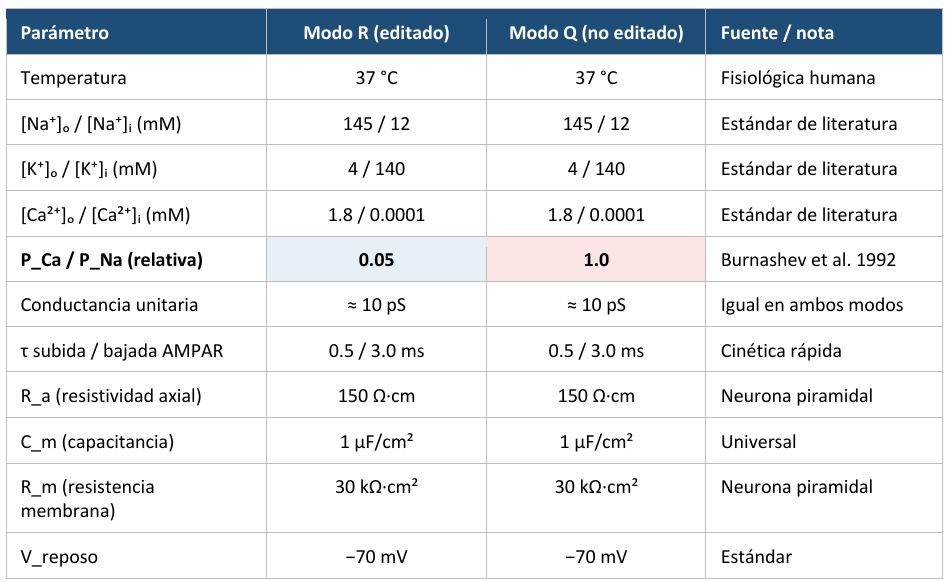

**LIBRERIAS**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

NumPy: cálculos matemáticos y manejo de arreglos.
Matplotlib: generación de gráficas I-V.
Pandas: creación y organización de tablas de resultados.

**PARÁMETROS FISIOLÓGICOS**

In [2]:
# Concentraciones iónicas (mM)

Na_o = 145
Na_i = 12

K_o = 4
K_i = 140

Ca_o = 1.8
Ca_i = 0.0001

# Permeabilidades relativas

P_Na = 1
P_K = 0.7

P_Ca_R = 0.05
P_Ca_Q = 1.0

# Conductancia unitaria

g = 10e-12  # 10 pS

# Constantes físicas

R = 8.314      # J/mol*K
T = 310.15     # Kelvin (37°C)
F = 96485      # C/mol

Estos valores replican las concentraciones fisiológicas reales de iones en una neurona humana. El gradiente de Ca²⁺ (~18,000:1) es enorme, lo que explica su gran influencia en el potencial.

**ECUACIÓN DE NERNST**

In [3]:
def nernst(out, inside, z):
    return (61.5 / z) * np.log10(out / inside)

Calcula el potencial de equilibrio para un ion específico. La fórmula es una versión simplificada de:

Eion = (RT/zF) · ln([ion]o/[ion]i)

donde 61.5 mV es el factor RT/F · 2.303 a 37°C, y z es la carga del ion.

**CÁLCULO DE POTENCIALES**

In [4]:
E_Na = nernst(Na_o, Na_i, 1)
E_K = nernst(K_o, K_i, 1)
E_Ca = nernst(Ca_o, Ca_i, 2)

print(f"E_Na = {E_Na:.2f} mV")
print(f"E_K = {E_K:.2f} mV")
print(f"E_Ca = {E_Ca:.2f} mV")

E_Na = 66.55 mV
E_K = -94.96 mV
E_Ca = 130.85 mV


**ECUACIÓN GHK**

In [5]:
def ghk(P_Ca):

    numerator = (
        P_Na * Na_o +
        P_K * K_o +
        4 * P_Ca * Ca_o
    )

    denominator = (
        P_Na * Na_i +
        P_K * K_i +
        4 * P_Ca * Ca_i
    )

    Vrev = (R * T / F) * np.log(numerator / denominator)

    return Vrev * 1000

La ecuación GHK pondera las permeabilidades de todos los iones para calcular el potencial de inversión (Vrev) — el voltaje al que la corriente neta es cero.
El factor 4 para el Ca²⁺ viene de z² (carga = 2, entonces 2² = 4), que pondera más fuertemente a los iones divalentes.


**Vrev EN MODO R Y Q**

In [6]:
Vrev_R = ghk(P_Ca_R)
Vrev_Q = ghk(P_Ca_Q)

delta_Vrev = Vrev_Q - Vrev_R

print(f"Vrev modo R = {Vrev_R:.2f} mV")
print(f"Vrev modo Q = {Vrev_Q:.2f} mV")
print(f"ΔVrev = {delta_Vrev:.2f} mV")

Vrev modo R = 7.96 mV
Vrev modo Q = 9.17 mV
ΔVrev = 1.21 mV


Interpretación biológica: En modo Q (alta permeabilidad al Ca²⁺), el Vrev se desplaza hacia valores más positivos, favoreciendo la entrada de Ca²⁺ y la excitotoxicidad.

**CURVAS I-V**

In [7]:
Vm = np.arange(-100, 65, 5)

I_R = g * (Vm - Vrev_R)
I_Q = g * (Vm - Vrev_Q)

Usa la ley de Ohm generalizada: la corriente es proporcional a la diferencia entre el voltaje de membrana y el potencial de inversión.
La gráfica muestra:

Línea azul → Modo R (editado, poco permeable al Ca²⁺)
Línea roja → Modo Q (no editado, muy permeable al Ca²⁺)
Líneas discontinuas → Marcan los Vrev de cada modo
Puntos → Intersecciones con el eje de corriente = 0

**GRAFICACION DE LAS CURVAS**

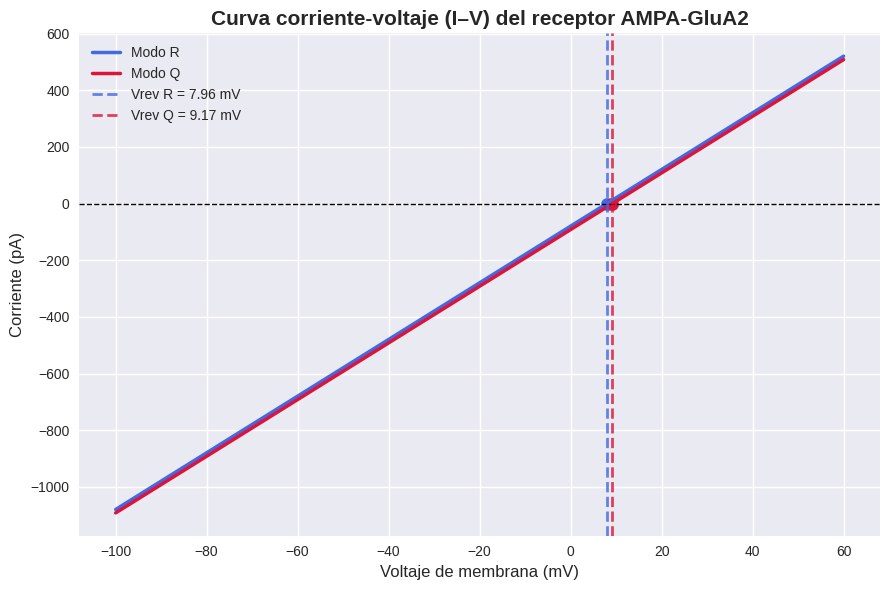

In [8]:
plt.style.use('seaborn-v0_8')

plt.figure(figsize=(9,6))

plt.plot(Vm, I_R * 1e12,
         color='royalblue',
         linewidth=2.5,
         label='Modo R')

plt.plot(Vm, I_Q * 1e12,
         color='crimson',
         linewidth=2.5,
         label='Modo Q')

plt.axhline(0,
            color='black',
            linestyle='--',
            linewidth=1)

plt.axvline(Vrev_R,
            color='royalblue',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Vrev R = {Vrev_R:.2f} mV')

plt.axvline(Vrev_Q,
            color='crimson',
            linestyle='--',
            linewidth=2,
            alpha=0.8,
            label=f'Vrev Q = {Vrev_Q:.2f} mV')

plt.scatter(Vrev_R, 0,
            color='royalblue',
            s=80)

plt.scatter(Vrev_Q, 0,
            color='crimson',
            s=80)

plt.xlabel('Voltaje de membrana (mV)', fontsize=12)

plt.ylabel('Corriente (pA)', fontsize=12)

plt.title('Curva corriente-voltaje (I–V) del receptor AMPA-GluA2',
          fontsize=15,
          fontweight='bold')

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig('Figura2_IV_curve.png',
            dpi=300)

plt.show()

**TABLA DE RESULTADOS**

In [9]:
tabla = pd.DataFrame({

    'Parámetro': [
        'E_Na',
        'E_K',
        'E_Ca',
        'Vrev_R',
        'Vrev_Q',
        'Delta_Vrev'
    ],

    'Valor (mV)': [
        E_Na,
        E_K,
        E_Ca,
        Vrev_R,
        Vrev_Q,
        delta_Vrev
    ]
})

tabla

,Parámetro,Valor (mV)
0,E_Na,66.554486
1,E_K,-94.960185
2,E_Ca,130.849630
3,Vrev_R,7.959110
4,Vrev_Q,9.165192
5,Delta_Vrev,1.206082


Resume todos los potenciales calculados y los exporta como archivo CSV.

**EXPORTAR TABLA A CSV**

In [10]:
tabla.to_csv('Tabla1_potenciales.csv', index=False)

**DISCUSION E INTERPRETACION BIOLOGICA**

**1. Modificación de la Permeabilidad al ca2+ (Modo R vs. Modo Q)**
La edición post-transcripcional de ARN mediada por la enzima ADAR2 sustituye una Glutamina (Q) codificada genéticamente por una Arginina (R) con carga positiva en la subunidad GluA2 del receptor AMPA. Los fundamentos del modelo demuestran que este cambio es altamente significativo: el modo editado (R) introduce una repulsión electrostática que vuelve al canal impermeable al ca2+, mostrando una relación corriente-voltaje lineal y baja conductancia de canal único. Por el contrario, la ausencia de edición en el modo (Q) elimina esta barrera, haciendo al receptor permeable al ca2+, otorgándole mayor conductancia y convirtiéndolo en un rectificador interno debido al bloqueo dependiente del voltaje por poliaminas intracelulares endógenas.

**2. Alteración del Potencial de Inversión (Vrev) y Excitotoxicidad**
A través del modelado computacional con la ecuación de Goldman-Hodgkin-Katz (GHK), los resultados de la simulación arrojan los siguientes valores exactos:
Vrev Modo R: 7.96 mV
Vrev Modo Q: 9.17 mV
Desplazamiento (ΔV rev): 1.206 mV hacia valores más despolarizados
Biológicamente, este corrimiento positivo confirma una alteración en la fuerza impulsora (driving force), lo que favorece la entrada de ca2+ y la excitotoxicidad. A diferencia de los receptores NMDA, los AMPA en modo Q permiten la inyección de ca2+ directamente a potenciales de reposo de forma independiente de voltaje. Este flujo masivo e incontrolado desequilibra la homeostasis iónica celular, provocando sobrecarga de calcio, disfunción mitocondrial, estrés celular y la activación de proteasas líticas que desencadenan la hiperexcitabilidad y muerte neuronal por excitotoxicidad.


**3. Conexión con Ansiedad, TEPT y Neurodegeneración en la Amígdala**
Esta disfunción biofísica se conecta de manera directa con afecciones neurológicas y psiquiátricas mapeadas en las neuronas piramidales de la amígdala basolateral (BLA):
Ansiedad y TEPT: Un déficit en la eficiencia de la edición de ADAR2 incrementa drásticamente la ganancia sináptica e induce hiperexcitabilidad amigdalina. Clínicamente, esto se traduce en una hiperreactividad de la amígdala ante estímulos neutros o mal discriminados, impidiendo los procesos de extinción del miedo y consolidando circuitos de ansiedad crónica y estrés postraumático (TEPT).
Neurodegeneración Excitotóxica: La entrada continuada de ca2+ a través de los receptores GluA2(Q) destruye progresivamente el citoesqueleto y la integridad de las neuronas piramidales de la amígdala. Esta atrofia estructural y pérdida de sustrato neuronal correlaciona directamente las respuestas graves al trauma psíquico con procesos de neurodegeneración focalizada acelerada.



**REFERENCIAS BIBLIOGRAFICAS**

-Isaac, J. T. R., Ashby, M. C., & McBain, C. J. (2007). The role of the GluR2 subunit in AMPA receptor function and synaptic plasticity. Neuron, 54(6), 859–871. https://doi.org/10.1016/j.neuron.2007.06.001


-D. E. Goldman, "Potential, impedance, and rectification in membranes," Journal of General Physiology, vol. 27, no. 1, pp. 37–60, Sep. 1943. doi: 10.1085/jgp.27.1.37


-La disfunción de ADAR2 en la ELA esporádica produce déficits en la edición Q/R de GluA2, resultando en receptores AMPA permeables al Ca²⁺ que contribuyen a la excitotoxicidad inducida por calcio. M. A. Doble et al., "ADAR2 mislocalization and widespread RNA editing aberrations in C9orf72-mediated ALS/FTD," Acta Neuropathologica, vol. 138, no. 2, pp. 241–257, 2019. doi: 10.1007/s00401-019-02054-4


-D. E. Goldman, "Potential, impedance, and rectification in membranes," Journal of General Physiology, vol. 27, no. 1, pp. 37–60, Sep. 1943. doi: 10.1085/jgp.27.1.37
